<class 'pandas.core.frame.DataFrame'>
Index: 34756 entries, 7 to 64154
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       34756 non-null  object 
 1   EdLevel       34188 non-null  object 
 2   YearsCodePro  34621 non-null  object 
 3   Employment    34717 non-null  object 
 4   Salary        34756 non-null  float64
dtypes: float64(1), object(4)
memory usage: 1.6+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 30019 entries, 7 to 64154
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       30019 non-null  object 
 1   EdLevel       30019 non-null  object 
 2   YearsCodePro  30019 non-null  object 
 3   Salary        30019 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.1+ MB

Training Linear Regression Model...
Accuracy (Linear Regression): 0.80, RMSE: 39375.72, MAE: 30606.09, R²: 0.33
Confusion Matrix (

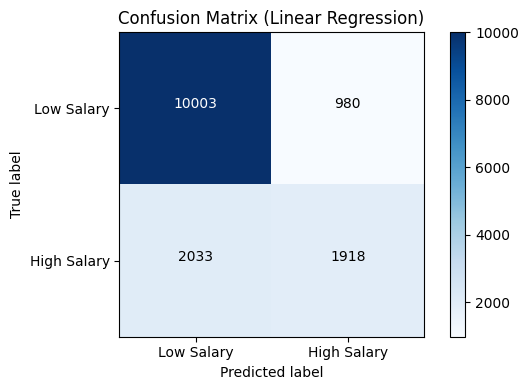


Training Decision Tree Regressor...
Accuracy (Decision Tree): 0.84, RMSE: 29917.50, MAE: 20485.14, R²: 0.61
Confusion Matrix (Decision Tree):
True Negatives (TN): 9494
False Positives (FP): 1489
False Negatives (FN): 947
True Positives (TP): 3004


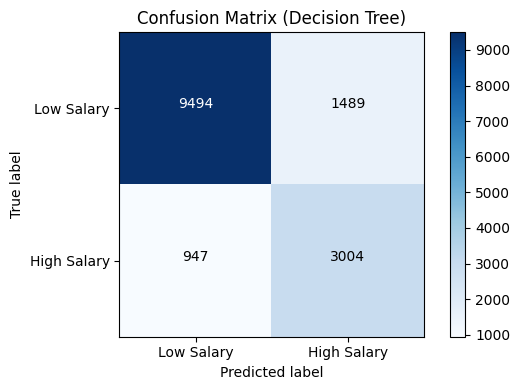


Training Random Forest Regressor...
Accuracy (Random Forest): 0.84, RMSE: 29961.40, MAE: 20583.78, R²: 0.61
Confusion Matrix (Random Forest):
True Negatives (TN): 9497
False Positives (FP): 1486
False Negatives (FN): 957
True Positives (TP): 2994


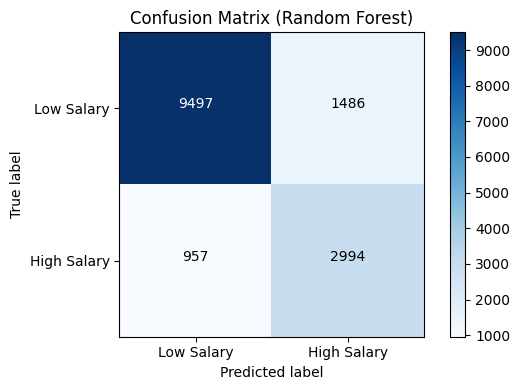

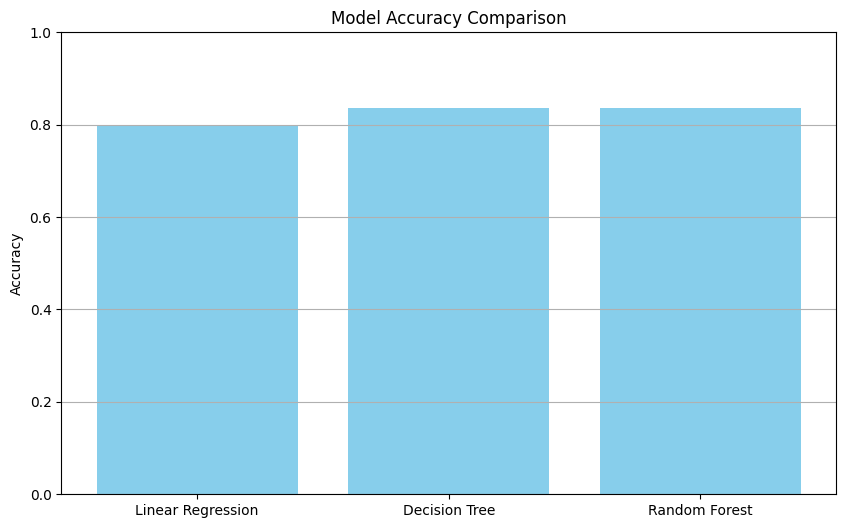

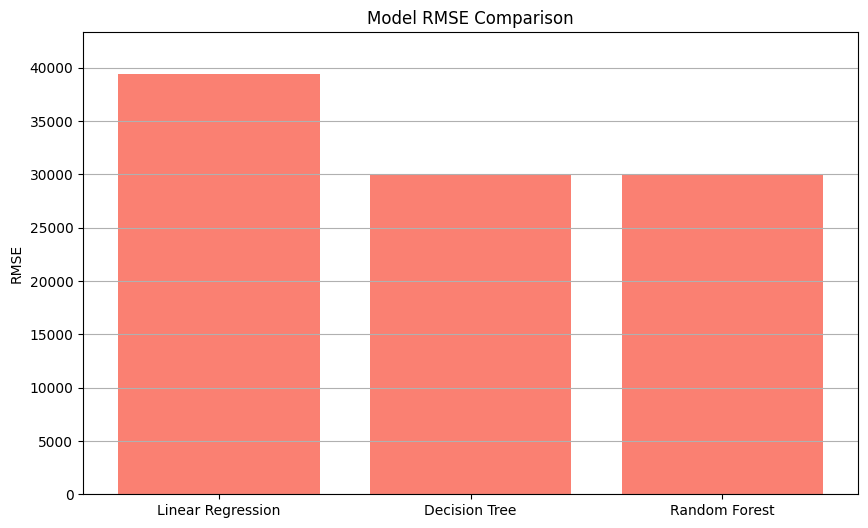

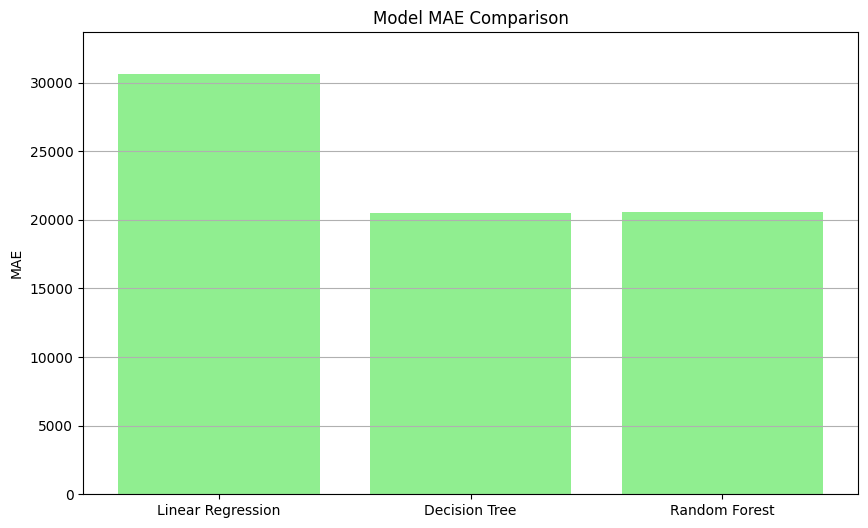

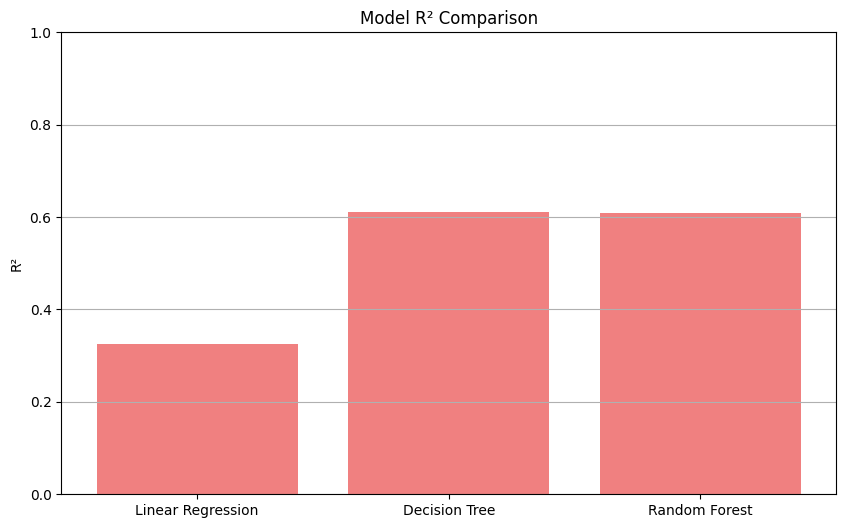

The best model based on accuracy is: Decision Tree
The best model based on RMSE is: Decision Tree
Predicted Salary: $148,098.30
Confusion Matrix:
True Negatives (TN): 9494
False Positives (FP): 1489
False Negatives (FN): 947
True Positives (TP): 3004
The best model based on accuracy is: Decision Tree
Confusion Matrix for the Best Model:
True Negatives (TN): 9494
False Positives (FP): 1489
False Negatives (FN): 947
True Positives (TP): 3004


C:\Users\SANJAY\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


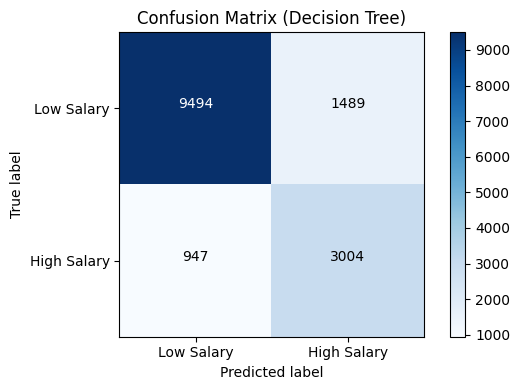


Accuracy: 83.69%

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.89     10983
           1       0.67      0.76      0.71      3951

    accuracy                           0.84     14934
   macro avg       0.79      0.81      0.80     14934
weighted avg       0.85      0.84      0.84     14934



In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
)

# Load dataset
df = pd.read_csv("survey_results_public.csv")
df.head()

# Prepare data
df = df[["Country", "EdLevel", "YearsCodePro", "Employment", "ConvertedComp"]]
df = df.rename({"ConvertedComp": "Salary"}, axis=1)
df.head()
df = df[df["Salary"].notnull()]
df.head()
df.info()

df = df.dropna()
df.isnull().sum()
df = df[df["Employment"] == "Employed full-time"]
df = df.drop("Employment", axis=1)
df.info()

# Country value counts
df['Country'].value_counts()

# Function to shorten categories
def shorten_categories(categories, cutoff):
    categorical_map = {}
    for i in range(len(categories)):
        if categories.values[i] >= cutoff:
            categorical_map[categories.index[i]] = categories.index[i]
        else:
            categorical_map[categories.index[i]] = 'Other'
    return categorical_map

# Map countries
country_map = shorten_categories(df.Country.value_counts(), 400)
df['Country'] = df['Country'].map(country_map)
df.Country.value_counts()

# Filter salaries
df = df[df["Salary"] <= 250000]
df = df[df["Salary"] >= 10000]
df = df[df['Country'] != 'Other']

# Clean Years of Professional Experience
df["YearsCodePro"].unique()

def clean_experience(x):
    if x == 'More than 50 years':
        return 50
    if x == 'Less than 1 year':
        return 0.5
    return float(x)

df['YearsCodePro'] = df['YearsCodePro'].apply(clean_experience)

# Clean Education Levels
df["EdLevel"].unique()

def clean_education(x):
    if 'Bachelor’s degree' in x:
        return 'Undergraduate'
    if 'Master’s degree' in x or 'Professional degree' in x or 'Other doctoral' in x:
        return 'Postgraduate'
    return None  

df['EdLevel'] = df['EdLevel'].apply(clean_education)

# Drop rows with None (for the removed 'Less than a Bachelor's degree')
df = df[df['EdLevel'].notnull()]
df["EdLevel"].unique()

# Label encoding
le_education = LabelEncoder()
df['EdLevel'] = le_education.fit_transform(df['EdLevel'])
df["EdLevel"].unique()

le_country = LabelEncoder()
df['Country'] = le_country.fit_transform(df['Country'])
df["Country"].unique()

# Define features and target
X = df.drop("Salary", axis=1)
y = df["Salary"]

# Create a binary target variable for salary classification (e.g., high salary vs. low salary)
threshold = 100000  # Define a threshold for high salary
y_binary = (y > threshold).astype(int)  # 1 for high salary, 0 for low salary

# Initialize dictionaries to store accuracy, RMSE, MAE, and R² values
results = {}

# -------------------- Linear Regression --------------------
print("\nTraining Linear Regression Model...")
linear_reg = LinearRegression()
linear_reg.fit(X, y.values)
y_pred_linear = linear_reg.predict(X)

# Calculate metrics for Linear Regression
y_pred_binary_linear = (y_pred_linear > threshold).astype(int)  # Convert predictions to binary
accuracy_linear = accuracy_score(y_binary, y_pred_binary_linear)
rmse_linear = np.sqrt(mean_squared_error(y, y_pred_linear))
mae_linear = mean_absolute_error(y, y_pred_linear)
r2_linear = r2_score(y, y_pred_linear)
results['Linear Regression'] = {'Accuracy': accuracy_linear, 'RMSE': rmse_linear, 'MAE': mae_linear, 'R²': r2_linear}
print(f"Accuracy (Linear Regression): {accuracy_linear:.2f}, RMSE: {rmse_linear:.2f}, MAE: {mae_linear:.2f}, R²: {r2_linear:.2f}")

# Confusion Matrix for Linear Regression
cm_linear = confusion_matrix(y_binary, y_pred_binary_linear)
tn_linear, fp_linear, fn_linear, tp_linear = cm_linear.ravel()
print("Confusion Matrix (Linear Regression):")
print(f"True Negatives (TN): {tn_linear}")
print(f"False Positives (FP): {fp_linear}")
print(f"False Negatives (FN): {fn_linear}")
print(f"True Positives (TP): {tp_linear}")


# ----- Display confusion matrix for Linear Regression in chart form -----
plt.figure(figsize=(6, 4))
plt.imshow(cm_linear, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Linear Regression)')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Low Salary', 'High Salary'])
plt.yticks(tick_marks, ['Low Salary', 'High Salary'])
thresh = cm_linear.max() / 2.
for i, j in np.ndindex(cm_linear.shape):
    plt.text(j, i, cm_linear[i, j], horizontalalignment='center',
             color='white' if cm_linear[i, j] > thresh else 'black')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()


# -------------------- Decision Tree Regressor --------------------
print("\nTraining Decision Tree Regressor...")
dec_tree_reg = DecisionTreeRegressor(random_state=0)
dec_tree_reg.fit(X, y.values)
y_pred_tree = dec_tree_reg.predict(X)

# Calculate metrics for Decision Tree
y_pred_binary_tree = (y_pred_tree > threshold).astype(int)  # Convert predictions to binary
accuracy_tree = accuracy_score(y_binary, y_pred_binary_tree)
rmse_tree = np.sqrt(mean_squared_error(y, y_pred_tree))
mae_tree = mean_absolute_error(y, y_pred_tree)
r2_tree = r2_score(y, y_pred_tree)
results['Decision Tree'] = {'Accuracy': accuracy_tree, 'RMSE': rmse_tree, 'MAE': mae_tree, 'R²': r2_tree}
print(f"Accuracy (Decision Tree): {accuracy_tree:.2f}, RMSE: {rmse_tree:.2f}, MAE: {mae_tree:.2f}, R²: {r2_tree:.2f}")

# Confusion Matrix for Decision Tree
cm_tree = confusion_matrix(y_binary, y_pred_binary_tree)
tn_tree, fp_tree, fn_tree, tp_tree = cm_tree.ravel()
print("Confusion Matrix (Decision Tree):")
print(f"True Negatives (TN): {tn_tree}")
print(f"False Positives (FP): {fp_tree}")
print(f"False Negatives (FN): {fn_tree}")
print(f"True Positives (TP): {tp_tree}")


# ----- Display confusion matrix for Decision Tree in chart form -----
plt.figure(figsize=(6, 4))
plt.imshow(cm_tree, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Decision Tree)')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Low Salary', 'High Salary'])
plt.yticks(tick_marks, ['Low Salary', 'High Salary'])
thresh = cm_tree.max() / 2.
for i, j in np.ndindex(cm_tree.shape):
    plt.text(j, i, cm_tree[i, j], horizontalalignment='center',
             color='white' if cm_tree[i, j] > thresh else 'black')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# -------------------- Random Forest Regressor --------------------
print("\nTraining Random Forest Regressor...")
random_forest_reg = RandomForestRegressor(random_state=0)
random_forest_reg.fit(X, y.values)
y_pred_forest = random_forest_reg.predict(X)

# Calculate metrics for Random Forest
y_pred_binary_forest = (y_pred_forest > threshold).astype(int)  # Convert predictions to binary
accuracy_forest = accuracy_score(y_binary, y_pred_binary_forest)
rmse_forest = np.sqrt(mean_squared_error(y, y_pred_forest))
mae_forest = mean_absolute_error(y, y_pred_forest)
r2_forest = r2_score(y, y_pred_forest)
results['Random Forest'] = {'Accuracy': accuracy_forest, 'RMSE': rmse_forest, 'MAE': mae_forest, 'R²': r2_forest}
print(f"Accuracy (Random Forest): {accuracy_forest:.2f}, RMSE: {rmse_forest:.2f}, MAE: {mae_forest:.2f}, R²: {r2_forest:.2f}")

# Confusion Matrix for Random Forest
cm_forest = confusion_matrix(y_binary, y_pred_binary_forest)
tn_forest, fp_forest, fn_forest, tp_forest = cm_forest.ravel()
print("Confusion Matrix (Random Forest):")
print(f"True Negatives (TN): {tn_forest}")
print(f"False Positives (FP): {fp_forest}")
print(f"False Negatives (FN): {fn_forest}")
print(f"True Positives (TP): {tp_forest}")


# ----- Display confusion matrix for Random Forest in chart form -----
plt.figure(figsize=(6, 4))
plt.imshow(cm_forest, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Random Forest)')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Low Salary', 'High Salary'])
plt.yticks(tick_marks, ['Low Salary', 'High Salary'])
thresh = cm_forest.max() / 2.
for i, j in np.ndindex(cm_forest.shape):
    plt.text(j, i, cm_forest[i, j], horizontalalignment='center',
             color='white' if cm_forest[i, j] > thresh else 'black')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()


# -------------------- Plotting Metrics for All Models --------------------
# Plotting accuracy for all models
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), [v['Accuracy'] for v in results.values()], color='skyblue')
plt.ylim(0, 1)  # Set y-axis limits to show accuracy percentage
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.grid(axis='y')
plt.show()

# Plotting RMSE for all models
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), [v['RMSE'] for v in results.values()], color='salmon')
plt.ylim(0, max([v['RMSE'] for v in results.values()]) * 1.1)  # Set y-axis limits
plt.ylabel('RMSE')
plt.title('Model RMSE Comparison')
plt.grid(axis='y')
plt.show()

# Plotting MAE for all models
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), [v['MAE'] for v in results.values()], color='lightgreen')
plt.ylim(0, max([v['MAE'] for v in results.values()]) * 1.1)  # Set y-axis limits
plt.ylabel('MAE')
plt.title('Model MAE Comparison')
plt.grid(axis='y')
plt.show()

# Plotting R² for all models
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), [v['R²'] for v in results.values()], color='lightcoral')
plt.ylim(0, 1)  # Set y-axis limits
plt.ylabel('R²')
plt.title('Model R² Comparison')
plt.grid(axis='y')
plt.show()

# Determine the best model based on accuracy and RMSE
best_accuracy_model = max(results, key=lambda x: results[x]['Accuracy'])
best_rmse_model = min(results, key=lambda x: results[x]['RMSE'])

print(f"The best model based on accuracy is: {best_accuracy_model}")
print(f"The best model based on RMSE is: {best_rmse_model}")

# Save model
data = {"model": best_rmse_model == 'Linear Regression' and linear_reg or best_rmse_model == 'Decision Tree' and dec_tree_reg or best_rmse_model == 'Random Forest' and random_forest_reg,
        "le_country": le_country, "le_education": le_education}
with open('saved_steps.pkl', 'wb') as file:
    pickle.dump(data, file)

# Load model
with open('saved_steps.pkl', 'rb') as file:
    data = pickle.load(file)

regressor_loaded = data["model"]
le_country = data["le_country"]
le_education = data["le_education"]

# Prepare data for prediction
X_new = np.array([["United States", 'Postgraduate', 15]])
X_new[:, 0] = le_country.transform(X_new[:, 0])
X_new[:, 1] = le_education.transform(X_new[:, 1])
X_new = X_new.astype(float)

# Predict salary
y_pred = regressor_loaded.predict(X_new)
print(f"Predicted Salary: ${y_pred[0]:,.02f}")

# Confusion Matrix (TP, TN, FP, FN) Implementation
# Create binary true and predicted values
y_pred_binary = (regressor_loaded.predict(X) > threshold).astype(int)  # Predicted labels

# Calculate confusion matrix
cm = confusion_matrix(y_binary, y_pred_binary)
tn, fp, fn, tp = cm.ravel()

# Print the results
print("Confusion Matrix:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# Determine the best model based on accuracy
best_model_name = best_accuracy_model  # Use the model with the highest accuracy
print(f"The best model based on accuracy is: {best_model_name}")

# Get the confusion matrix for the best model
if best_model_name == 'Linear Regression':
    cm_best = cm_linear
elif best_model_name == 'Decision Tree':
    cm_best = cm_tree
else:
    cm_best = cm_forest

# Print and display the confusion matrix for the best model
print("Confusion Matrix for the Best Model:")
tn_best, fp_best, fn_best, tp_best = cm_best.ravel()
print(f"True Negatives (TN): {tn_best}")
print(f"False Positives (FP): {fp_best}")
print(f"False Negatives (FN): {fn_best}")
print(f"True Positives (TP): {tp_best}")

# ----- Display confusion matrix for the best model in chart form -----
plt.figure(figsize=(6, 4))
plt.imshow(cm_best, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix ({best_model_name})')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Low Salary', 'High Salary'])
plt.yticks(tick_marks, ['Low Salary', 'High Salary'])
thresh = cm_best.max() / 2.
for i, j in np.ndindex(cm_best.shape):
    plt.text(j, i, cm_best[i, j], horizontalalignment='center',
             color='white' if cm_best[i, j] > thresh else 'black')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Calculate accuracy percentage
accuracy = accuracy_score(y_binary, y_pred_binary) * 100
print(f"\nAccuracy: {accuracy:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_binary, y_pred_binary))
